### General advice (delete this cell before submitting for review)

> * When adding **Products used**, embed the hyperlink to that specific product on the DE Africa Explorer using the `[product_name](product url)` syntax.
> * When writing in Markdown cells, start each sentence on a **new line**.
This makes it easy to see changes through git commits.
> * To faciliate the easy conversion of these notebooks into a docs help page, check the [known issues](https://github.com/GeoscienceAustralia/dea-docs/wiki/Known-issues) for formatting regarding the conversion of notebooks to DE Africa docs using Sphinx.
Things to be aware of:
    * Sphinx is highly sensitive to bulleted lists:
        * Ensure that there is an empty line between any preceding text and the list
        * Only use the `*` bullet (`-` is not recognised)
        * Sublists must be indented by 4 spaces
    * Two kinds of formatting cannot be used simultaneously:
        * Hyperlinked code: \[\`code_format\`](hyperlink) fails
        * Bolded code: \*\*\`code_format\`\*\* fails
    * Headers must appear in hierarchical order (`#`, `##`, `###`, `####`) and there can only be one title (`#`).
> * Use the [PEP8 standard](https://www.python.org/dev/peps/pep-0008/) for code. To make sure all code in the notebook is consistent, you can use the `jupyterlab_code_formatter` tool: select each code cell, then click `Edit` and then one of the `Apply X Formatter` options (`YAPF` or `Black` are recommended). This will reformat the code in the cell to a consistent style.
> * In the final notebook cell, include a set of relevant **keywords** which are used to build the DE Africa User Guide's [Keyword Index](https://docs.digitalearthafrica.org/en/latest/genindex.html).
    * Use the list of approved documentation keywords on the [wiki page](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks/wiki/List-of-Documentation-Keywords).
    * Avoid using keywords that link to specific modules in `deafrica_tools`.
    * Use all lower-case (unless the tag is an acronym), separate words with spaces. Note that Sentinel satellites are canonically named with hyphens connecting name and number, while Landsat satellites are not: `sentinel-2`, `landsat 8`
    * Ensure the keywords cell below is in `Raw` format, rather than `Markdown` or `Code`.
    
> * Graphics should use appropriate colour-contrasting schemes to maximise accessibility to people with vision impairment. For example, avoid Red-to-Green colour schemes and rainbow palettes. For more information and to test if your graphics are colour-vision impaired friendly, see tools such as [Coblis](https://www.color-blindness.com/coblis-color-blindness-simulator/) or [TPGI](https://www.tpgi.com/color-contrast-checker/)

# Descriptive title that follows notebook filename

* **Products used:** 
[wq_annual](https://explorer.dev.digitalearth.africa/products/wq_annual),
[ls8_sr](https://explorer.digitalearth.africa/products/ls8_sr),
[wofs_ls_summary_annual](https://explorer.digitalearth.africa/wofs_ls_summary_annual)
* **Special requirements:** An _optional_ description of any special requirements
* **Prerequisites:** An _optional_ list of any notebooks that should be run or content that should be understood prior to launching this notebook


## Background
An *optional* overview of the scientific, economic or environmental management issue or challenge being addressed by Digital Earth Africa. 
For `Beginners_Guide` or `Frequently_Used_Code` notebooks, this may include information about why the particular technique or approach is useful or required. 
If you need to cite a scientific paper or link to a website, use a persistent DOI link if possible and link in-text (e.g. [Dhu et al. 2017](https://doi.org/10.1080/20964471.2017.1402490)).

## Description
A _compulsory_ description of the notebook, including a brief overview of how Digital Earth Africa helps to address the problem set out above.
It can be good to include a run-down of the tools/methods that will be demonstrated in the notebook:

1. First we do this
2. Then we do this
3. Finally we do this

***

## Getting started

Provide any particular instructions that the user might need, e.g. To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages
Import Python packages that are used for the analysis.

Use standard import commands; some are shown below. 
Begin with any `iPython` magic commands, followed by standard Python packages, then any additional functionality you need from the `Tools` package.

In [1]:
%matplotlib inline

import datacube
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from pystac_client import Client
from odc.stac import configure_rio, stac_load
from odc.geo import BoundingBox

import sys
sys.path.append("/home/jovyan/deafrica_water_quality/src")
from water_quality.mapping.fai import FAI

### Connect to the datacube

Connect to the datacube so we can access DE Africa data.
The `app` parameter is a unique name for the analysis which is based on the notebook file name.

In [2]:
dc = datacube.Datacube(app='DEA_notebooks_template')

### Analysis parameters

An *optional* section to inform the user of any parameters they'll need to configure to run the notebook:

* `param_name_1`: Simple description (e.g. `example_value`). Advice about appropriate values to choose for this parameter.
* `param_name_2`: Simple description (e.g. `example_value`). Advice about appropriate values to choose for this parameter.


In [3]:
param_name_1 = 'example_value'
param_name_2 = 'example_value'

## Load water quality data derived from annual geomedians
Use headings to break up key steps/stages of the notebook.

Use markdown text for detailed, descriptive text explaining what the code below does and why it is needed.

> **Note:** Use this markdown format (sparingly) to draw particular attention to an important point or caveat

In [4]:
configure_rio(
    cloud_defaults=True,
    aws={"aws_unsigned": True},
    AWS_S3_ENDPOINT="s3.af-south-1.amazonaws.com",
)

In [5]:
# Open the stac catalogue
catalog = Client.open("https://explorer.dev.digitalearth.africa/stac")

In [6]:
# Set a bounding box
# [xmin, ymin, xmax, ymax] in latitude and longitude
bbox = [32.80, -0.20, 33.05, 0.05]

# Set a start and end date
start_date = "2024-01-01"
end_date = "2024-02-28"

# Set the STAC collections
collections = ["wq_annual"]

In [7]:
BoundingBox(*bbox).explore()

In [8]:
# Build a query with the set parameters
query = catalog.search(
    bbox=bbox, collections=collections, datetime=f"{start_date}/{end_date}"
)

# Search the STAC catalog for all items matching the query
items = list(query.items())
print(f"Found: {len(items):d} datasets")

Found: 4 datasets


In [9]:
crs = "EPSG:6933"
resolution = 10

ds = stac_load(
    items,
    crs=crs,
    resolution=resolution,
    chunks={},
    bbox=bbox,
)

# View the Xarray Dataset
ds

<xarray.Dataset> Size: 739MB
Dimensions:          (y: 3190, x: 2413, time: 1)
Coordinates:
  * y                (y) float64 26kB 6.375e+03 6.365e+03 ... -2.552e+04
  * x                (x) float64 19kB 3.165e+06 3.165e+06 ... 3.189e+06
  * time             (time) datetime64[ns] 8B 2024-01-01
    spatial_ref      int32 4B 6933
Data variables: (12/24)
    tsi              (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    tsm              (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    chla             (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    agm_fai          (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    agm_hue          (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    agm_owt          (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    ...               ...
    tm_agm_ndvi      (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    msi_agm_ndvi     (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    oli_agm_ndvi     (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    tirs_st_ann_max  (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    tirs_st_ann_med  (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    tirs_st_ann_min  (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>

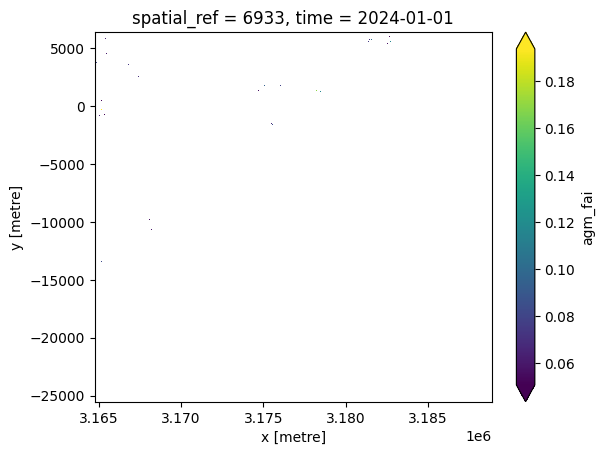

In [10]:
ds.agm_fai.plot(robust=True)

### Load in individual timestep Landsat data
Use subheadings to break up steps within a single section.

In [11]:
# Open the stac catalogue
catalog = Client.open("https://explorer.digitalearth.africa/stac")

In [12]:
# Build a query with the set parameters
query = catalog.search(
    bbox=bbox, collections=["ls8_sr"], datetime=f"{start_date}/{end_date}"
)

# Search the STAC catalog for all items matching the query
items = list(query.items())
print(f"Found: {len(items):d} datasets")

Found: 4 datasets


In [13]:
ls_ds = stac_load(
    items,
    crs=crs,
    resolution=30,
    chunks={},
    bbox=bbox,
)

In [14]:
ls_ds

<xarray.Dataset> Size: 151MB
Dimensions:                    (y: 1064, x: 805, time: 4)
Coordinates:
  * y                          (y) float64 9kB 6.375e+03 ... -2.552e+04
  * x                          (x) float64 6kB 3.165e+06 3.165e+06 ... 3.189e+06
  * time                       (time) datetime64[ns] 32B 2024-01-03T08:01:25....
    spatial_ref                int32 4B 6933
Data variables:
    SR_B1                      (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>
    SR_B2                      (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>
    SR_B3                      (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>
    SR_B4                      (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>
    SR_B5                      (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>
    SR_B6                      (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>
    SR_B7                      (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>
    QA_PIXEL                   (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>
    QA_RADSAT                  (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>
    SR_QA_AEROSOL              (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>
    reduced_resolution_browse  (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>

In [15]:
def rename_oli_bands(ds):
    rename_dict = {
        "SR_B2": "oli02",
        "SR_B3": "oli03",
        "SR_B4": "oli04",
        "SR_B5": "oli05",
        "SR_B6": "oli06",
        "SR_B7": "oli07",
    }
    
    # Only rename variables that actually exist in ds
    rename_dict = {k: v for k, v in rename_dict.items() if k in ds.data_vars}
    
    return ds.rename(rename_dict)

In [16]:
ds_ls = rename_oli_bands(ls_ds)

## Heading 2
Use markdown text for detailed, descriptive text explaining what the code below does and why it is needed.

In [17]:
# For centred 2024, attempt 2022–2026
search = catalog.search(
    collections=["wofs_ls_summary_annual"],
    bbox=bbox,
    datetime="2022-01-01/2025-12-31"
)

items = search.item_collection()

items

In [18]:
ds_wofs = stac_load(
    items,
    bbox=bbox,
    crs="EPSG:6933",
    resolution=30,
    chunks={}
)

In [19]:
wet_5yr = ds_wofs.count_wet.rolling(
    time=5,
    center=True,
    min_periods=3
).sum()

clear_5yr = ds_wofs.count_clear.rolling(
    time=5,
    center=True,
    min_periods=3
).sum()

freq_5yr = wet_5yr / clear_5yr

freq_2024 = freq_5yr.sel(time="2024")

In [20]:
fai_ls = FAI(ds_ls, instrument='oli')

In [21]:
wet_mask = freq_2024 > 0.5
wet_mask_expanded = wet_mask.isel(time=0).broadcast_like(fai_ls)
fai_ls_wet = xr.where(wet_mask_expanded, fai_ls, np.nan)

/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


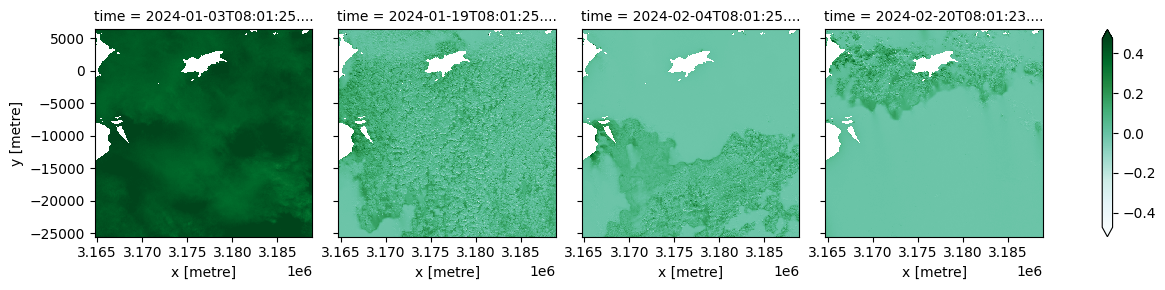

In [22]:
fai_ls_wet.plot(
    col="time",
    col_wrap=4, 
    cmap="BuGn",
    robust=True
)

In [23]:
# Define threshold
threshold = 0.1

# Compute spatial mean over y/x ignoring NaNs
mean_fai = fai_ls_wet.mean(dim=("y", "x"), skipna=True)

# Build a pandas DataFrame
fai_summary = pd.DataFrame({
    "time": mean_fai.time.values,
    "mean_fai": mean_fai.values,
    "above_threshold": mean_fai.values > threshold
})

# Light pastel colors for readability
def highlight_threshold(val):
    color = '#ff9999' if val else '#b3ffb3'  # light red / light green
    return f'background-color: {color}'

# Apply styling
fai_summary.style.map(highlight_threshold, subset=['above_threshold'])

/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


,time,mean_fai,above_threshold
0,2024-01-03 08:01:25.176404,0.426036,True
1,2024-01-19 08:01:25.862832,0.065402,False
2,2024-02-04 08:01:25.069829,0.024477,False
3,2024-02-20 08:01:23.472667,0.011803,False


***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Slack channel](http://slack.opendatacube.org/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

**Compatible datacube version:** 

In [24]:
print(datacube.__version__)

1.9.13


**Last Tested:**

In [25]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2026-03-02'